In [ ]:
# !pip install wrds

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import wrds

In [4]:
#Establish connection
db = wrds.Connection()

# db.connection.rollback()

WRDS recommends setting up a .pgpass file.
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [10]:
def get_earnings_data(ticker_list, start_date, end_date, db):
    """
    Fetches quarterly earnings announcement dates and related data
    for a list of tickers within a specific date range.

    Parameters:
    - ticker_list (list of str): List of stock tickers (e.g., ['AAPL', 'MSFT']).
    - start_date (str): Start date in 'YYYY-MM-DD' format.
    - end_date (str): End date in 'YYYY-MM-DD' format.
    - db: WRDS database connection object.

    Returns:
    - pandas.DataFrame: Table of earnings data with columns [cusip, ticker, datadate, earnings_date, fyearq, fqtr].
    """

    if not ticker_list:
        return pd.DataFrame(columns=["cusip", "ticker", "datadate", "earnings_date", "fyearq", "fqtr"])

    formatted_tickers = "', '".join(ticker_list)

    query_earning = f"""
    SELECT cusip,
           tic as ticker,
           datadate,
           rdq as earnings_date,
           fyearq,
           fqtr
    FROM comp.fundq
    WHERE tic IN ('{formatted_tickers}')
      AND rdq BETWEEN '{start_date}' AND '{end_date}'
      AND rdq IS NOT NULL
    """

    return db.raw_sql(query_earning)


def get_index_holdings(index_name, db):
    """
    Fetch current holdings (company name and ticker) for a given index.

    Parameters:
    ----------
    index_name : str
        Name of the index (e.g., 'S&P 500', 'NASDAQ 100').
    db : object
        Database connection object with a .raw_sql() method.

    Returns:
    -------
    pd.DataFrame
        DataFrame containing indexname, companyname, and tic.
    """
    query = f"""
        SELECT *
        FROM comp_na_daily_all.wrds_idx_cst_current t
        WHERE indexname = '{index_name}'
    """
    holdings = db.raw_sql(query)
    return holdings

def get_earnings_data(ticker_list, start_date, end_date, db):
    """
    Fetches quarterly earnings announcement dates and related data
    for a list of tickers within a specific date range.

    Parameters:
    - ticker_list (list of str): List of stock tickers (e.g., ['AAPL', 'MSFT']).
    - start_date (str): Start date in 'YYYY-MM-DD' format.
    - end_date (str): End date in 'YYYY-MM-DD' format.
    - db: WRDS database connection object.

    Returns:
    - pandas.DataFrame: Table of earnings data with columns [cusip, ticker, datadate, earnings_date, fyearq, fqtr].
    """

    if not ticker_list:
        return pd.DataFrame(columns=["cusip", "ticker", "datadate", "earnings_date", "fyearq", "fqtr"])

    formatted_gvkeys = "', '".join(ticker_list)

    query_earning = f"""
    SELECT gvkey, cusip,
           tic as ticker,
           datadate,
           rdq as earnings_date,
           fyearq,
           fqtr
    FROM comp.fundq
    WHERE gvkey IN ('{formatted_gvkeys}')
      AND rdq BETWEEN '{start_date}' AND '{end_date}'
      AND rdq IS NOT NULL
    """

    return db.raw_sql(query_earning)


def get_ibes_summary_epsus(db, cusip_list, start_date='2005-01-01', end_date='2024-12-31'):
    """
    Query WRDS to get IBES EPS summary estimates for a list of CUSIPs.
    Filters for quarterly EPS forecasts only.

    Parameters:
        db (wrds.Connection): Active WRDS connection
        cusip_list (list): List of 8-digit CUSIPs
        start_date (str): Start date for statpers
        end_date (str): End date for statpers

    Returns:
        DataFrame with selected IBES fields
    """
    # Format CUSIPs for SQL IN clause
    cusip_list_str = ', '.join(f"'{cusip}'" for cusip in cusip_list)

    query = f"""
        SELECT ticker, cusip, statpers, fpedats, anndats_act,
               meanest, stdev, numest, fpi
        FROM tr_ibes.statsum_epsus
        WHERE cusip IN ({cusip_list_str})
          AND statpers BETWEEN '{start_date}' AND '{end_date}'
          AND measure = 'EPS'
          AND fiscalp = 'QTR'
    """

    # Run the query and parse dates
    df = db.raw_sql(query, date_cols=['statpers', 'fpedats', 'anndats_act'])
    return df

def filter_one_quarter_ahead(df):
    """
    Filters IBES summary estimates to keep only the next (nearest) unreported quarter
    for each (cusip, statpers) pair.

    Parameters:
        df (pd.DataFrame): IBES summary DataFrame

    Returns:
        pd.DataFrame: Filtered for one-quarter-ahead EPS forecasts
    """
    # Ensure dates are datetime
    df['statpers'] = pd.to_datetime(df['statpers'])
    df['fpedats'] = pd.to_datetime(df['fpedats'])
    df['anndats_act'] = pd.to_datetime(df['anndats_act'])

    # Filter for unannounced forward-looking forecasts
    mask_future = (df['fpedats'] > df['statpers']) & (
        df['anndats_act'].isna() | (df['anndats_act'] > df['statpers'])
    )
    df_future = df[mask_future].copy()

    # Sort and select earliest fpedats for each (cusip, statpers)
    df_next = (
        df_future.sort_values(['cusip', 'statpers', 'fpedats'])
        .groupby(['cusip', 'statpers'], as_index=False)
        .first()
    )

    # Optional: calculate normalized dispersion
    df_next['dispersion'] = df_next['stdev'] / df_next['meanest'].abs()

    return df_next




def get_latest_ticker_info(cusip_list, db):
    if not cusip_list:
        return pd.DataFrame(columns=["cusip", "ticker", "secid", "effect_date"])

    formatted_cusips = ', '.join(f"'{str(cusip)}'" for cusip in cusip_list)

    query = f"""
        SELECT cusip, ticker, secid, effect_date
        FROM (
            SELECT *,
                   ROW_NUMBER() OVER (PARTITION BY cusip ORDER BY effect_date DESC) AS rn
            FROM optionm_all.secnmd
            WHERE cusip IN ({formatted_cusips})
        ) sub
        WHERE rn = 1
        ORDER BY cusip;
    """
    return db.raw_sql(query)


def get_security_prices(secid_list, start_date, end_date, db):
    if not cusip_list:
        return pd.DataFrame()

    # Properly quote each CUSIP as a string
    formatted_secids = ', '.join(f"'{str(cusip)}'" for cusip in secid_list)

    # formatted_secids = ', '.join(str(s) for s in cusip_list)
    query = f"""
        SELECT *
        FROM optionm.secprd
        WHERE secid IN ({formatted_secids})
          AND date BETWEEN '{start_date}' AND '{end_date}'
        ORDER BY secid, date;
    """
    return db.raw_sql(query)


def compute_excess_return(prices_df, index_symbol='SPX'):
    prices_df['date'] = pd.to_datetime(prices_df['date'])
    index_df = prices_df[prices_df['ticker'] == index_symbol].copy()
    asset_df = prices_df[prices_df['ticker'] != index_symbol].copy()

    # Merge index returns
    asset_df = asset_df.merge(
        index_df[['date', 'return']].rename(columns={'return': 'return_index'}),
        on='date', how='left'
    )

    asset_df['excess_return'] = asset_df['return'] - asset_df['return_index']
    return asset_df.sort_values(['secid', 'date'])


def compute_ewma_realized_vol(asset_df, rolling_stdev_params):
    grouped = asset_df.groupby('ticker')

    for hl_label, halflife in rolling_stdev_params['HALFLIFE'].items():
        col_name = f'excess_ewm_std_expanding_hl{hl_label}'
        asset_df[col_name] = grouped['excess_return'].transform(
            lambda x: x.ewm(
                halflife=halflife,
                min_periods=rolling_stdev_params['min_periods']
            ).std() * np.sqrt(rolling_stdev_params['TRADING_DAYS'])
        )

    return asset_df


def compute_y_feature(asset_df, short_label='ST', long_label='MT'):
    short_col = f'excess_ewm_std_expanding_hl{short_label}'
    long_col = f'excess_ewm_std_expanding_hl{long_label}'

    asset_df['y_feature'] = asset_df[short_col] / asset_df[long_col]
    asset_df['y_feature'] = asset_df['y_feature'].rolling(window=5).mean()
    return asset_df[['ticker', 'secid', 'date', 'y_feature']].dropna()



def align_realized_vol_to_earnings(realized_vol_df, earnings_df, window=5):
    """
    Aligns post-earnings realized volatility (y_feature) to T+window.
    Assumes 'earnings_date' is in earnings_df and 'date' is in realized_vol_df.

    Returns:
        Merged DataFrame with y_feature at T+window for each earnings event.
    """
    earnings_df['earnings_date'] = pd.to_datetime(earnings_df['earnings_date'])
    realized_vol_df['date'] = pd.to_datetime(realized_vol_df['date'])

    # Merge and find the closest match for earnings_date + window
    target_dates = earnings_df.copy()
    target_dates['target_date'] = target_dates['earnings_date'] + pd.Timedelta(days=window)

    # Inner join to find exact matches
    merged = pd.merge(
        target_dates,
        realized_vol_df,
        left_on=['ticker', 'target_date'],
        right_on=['ticker', 'date'],
        how='left'
    )

    return merged.dropna(subset=['y_feature'])

def merge_with_ibes_dispersion(aligned_df, ibes_dispersion_df):
    """
    Joins realized volatility (y_feature) with IBES dispersion.
    Matches on ticker and fiscal period end date (fpedats ≈ earnings_date).
    """
    ibes_dispersion_df['fpedats'] = pd.to_datetime(ibes_dispersion_df['fpedats'])
    aligned_df['earnings_date'] = pd.to_datetime(aligned_df['earnings_date'])

    # Use fuzzy join logic: fpedats == fiscal quarter end matching earnings_date
    merged = pd.merge(
        aligned_df,
        ibes_dispersion_df[['ticker', 'fpedats', 'dispersion']],
        left_on=['ticker', 'fyearq'],
        right_on=['ticker', 'fpedats'],
        how='inner'
    )

    return merged.dropna(subset=['dispersion', 'y_feature'])



def plot_dispersion_vs_vol(df):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df, x='dispersion', y='y_feature', hue='ticker', alpha=0.6)
    plt.title("Analyst Dispersion vs. Realized Relative Volatility (T+5)")
    plt.xlabel("Analyst Dispersion (IBES)")
    plt.ylabel("Post-Earnings Relative Volatility (y_feature)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [11]:
# analysis_period = ['2022-01-01', '2023-01-01']

# sp500_holdings = get_index_holdings('S&P 500', db)
# earnings_date = get_earnings_data(sp500_holdings['gvkey'].to_list(), '2022-01-01', '2023-01-01', db)
# earnings_date['cusip8'] = earnings_date['cusip'].str[:8]
# analyst_estimates = get_ibes_summary_epsus(db,earnings_date.sort_values(by=['ticker'])['cusip8'].unique(), '2022-01-01', '2023-01-01')

# Define analysis period
start_date, end_date = '2022-01-01', '2023-01-01'

# Step 1: Get S&P 500 constituents
sp500_constituents = get_index_holdings('S&P 500', db)

# Step 2: Get earnings announcement dates for these firms
gvkey_list = sp500_constituents['gvkey'].tolist()
earnings_df = get_earnings_data(gvkey_list, start_date, end_date, db)

# Step 3: Extract 8-digit CUSIPs for matching with IBES
earnings_df['cusip8'] = earnings_df['cusip'].str[:8]

# Step 4: Get IBES analyst estimates using unique CUSIP8s
cusip_list = earnings_df['cusip8'].dropna().unique().tolist()
ibes_estimates = get_ibes_summary_epsus(db, cusip_list, start_date, end_date)


PendingRollbackError: Can't reconnect until invalid transaction is rolled back.  Please rollback() fully before proceeding (Background on this error at: https://sqlalche.me/e/20/8s2b)

### 📄 Dispersion of Analyst Estimates

We measure the **dispersion of analyst forecasts** using the standard deviation of their estimates, normalized by the absolute value of the consensus estimate. For a given stock \( i \) at estimation date \( t \), we compute:

$$
\text{Dispersion}_{i,t} = \frac{\sigma_{i,t}}{|\mu_{i,t}|}
$$

Where:


- $ \sigma_{i,t} $ is the **standard deviation** of analyst estimates for firm $ i $ at time $ t $
- $ \mu_{i,t} $ is the **mean (consensus)** estimate of analysts for firm $ i $ at time $ t $
- The denominator uses absolute value $ |\mu_{i,t}| $ to ensure **scale-invariant normalization**


---

### 📝 Interpretation and Comments

- **What it captures:**  
  High dispersion implies greater **disagreement** among analysts → a proxy for **uncertainty** or **information asymmetry**

- **Why normalize?**  
  Because a raw standard deviation is not comparable across firms with different earnings scales. Normalization makes dispersion **unit-free** and **comparable across firms and time**.

- **Applications:**  
  - As a signal of **forecast uncertainty** before earnings  
  - As a control in **regression models** of earnings surprise or return reactions  
  - In cross-sectional asset pricing to detect **mispricing** or **risk premia**


In [12]:
index_info = {'secid':108105.0,
              'cusip':'64881510',
              'ticker':'SPX'}


# === Configuration ===
start_date, end_date = '2022-01-01', '2023-01-01'
rolling_stdev_params = {
    'HALFLIFE': {'ST': 5, 'MT': 21},
    'min_periods': 10,
    'TRADING_DAYS': 252
}



securities_info = get_latest_ticker_info(cusip_list,db)

# Append index_info (as a row) to the securities_info DataFrame
index_df = pd.DataFrame([index_info])
securities_info = pd.concat([securities_info, index_df], ignore_index=True)
secid_lst = securities_info['secid'].tolist()


# === security prices for REVR ===
prices_df = get_security_prices(secid_lst, start_date, end_date, db)
# prices_df['secid'] = prices_df['secid'].astype(str)
prices_df = prices_df.merge(securities_info[['ticker', 'secid']], on='secid', how='left')

# # === Excess Return + EWMA Realized Vol ===
asset_df = compute_excess_return(prices_df, index_symbol=index_info['ticker']) ## DOUBLE CHECK THIS LOGIC
asset_df = compute_ewma_realized_vol(asset_df, rolling_stdev_params)
realized_vol_df = compute_y_feature(asset_df)


df = filter_one_quarter_ahead(ibes_estimates)

aligned_df = align_realized_vol_to_earnings(realized_vol_df, earnings_df)


NameError: name 'cusip_list' is not defined

In [ ]:
df['dispersion'] = df['stdev']

In [ ]:
# # get_ibes_summary_epsus(db,cusip_list, '2022-01-01', '2023-01-01')
# ibes_estimates
# Ensure date columns are datetime
df['statpers'] = pd.to_datetime(df['statpers'])

# Step 1: Get full business date range
full_dates = pd.date_range(df['statpers'].min(), df['statpers'].max(), freq='B')

# Step 2: Get unique CUSIPs
cusips = df['cusip'].unique()

# Step 3: Create cartesian product of cusip × date
panel_index = pd.MultiIndex.from_product([cusips, full_dates], names=['cusip', 'date'])
expanded_df = pd.DataFrame(index=panel_index).reset_index()

# Merge with original df on cusip + statpers → map dispersion values to statpers dates
df_renamed = df.rename(columns={'statpers': 'date'})
merged_disp = pd.merge(expanded_df, df_renamed[['cusip', 'date', 'dispersion']],
                       on=['cusip', 'date'], how='left')

# Forward fill dispersion per cusip
merged_disp['dispersion'] = merged_disp.groupby('cusip')['dispersion'].ffill()
merged_disp

,cusip,date,dispersion
0,00105510,2022-01-20,0.05
1,00105510,2022-01-21,0.05
2,00105510,2022-01-24,0.05
3,00105510,2022-01-25,0.05
4,00105510,2022-01-26,0.05
...,...,...,...
113511,V7780T10,2022-12-09,0.26
113512,V7780T10,2022-12-12,0.26
113513,V7780T10,2022-12-13,0.26
113514,V7780T10,2022-12-14,0.26


In [ ]:
aligned_df['earnings_date'] = pd.to_datetime(aligned_df['earnings_date'])

aligned_df['earnings_date'] = pd.to_datetime(aligned_df['earnings_date'])

# Use pandas offset for business days
from pandas.tseries.offsets import BDay

# Create new column: dispersion lookup date = T - 21 business days
aligned_df['dispersion_lookup_date'] = aligned_df['earnings_date'] - BDay(21)
aligned_df['cusip8'] = aligned_df['cusip'].str[:8]





# Merge on (cusip, date)
final_df = pd.merge(
    aligned_df,
    merged_disp,
    left_on=['cusip8', 'dispersion_lookup_date'],
    right_on=['cusip', 'date'],
    how='left'
)

# Drop extra 'date' column if needed
final_df = final_df.drop(columns=['date_y'])


# # Sample 3 random tickers that exist in your merged DataFrame
# sample_tickers = final_df['ticker'].dropna().unique()
# sample_tickers = pd.Series(sample_tickers).sample(3, random_state=42).tolist()

final_df

,gvkey,cusip_x,ticker,datadate,earnings_date,fyearq,fqtr,cusip8,target_date,secid,date_x,y_feature,dispersion_lookup_date,cusip_y,dispersion
0,002086,071813109,BAX,2021-12-31,2022-02-17,2021,4,07181310,2022-02-22,102043.0,2022-02-22,0.939342,2022-01-19,<NA>,<NA>
1,002086,071813109,BAX,2022-03-31,2022-04-28,2022,1,07181310,2022-05-03,102043.0,2022-05-03,1.116033,2022-03-30,07181310,0.02
2,002086,071813109,BAX,2022-06-30,2022-07-28,2022,2,07181310,2022-08-02,102043.0,2022-08-02,1.411863,2022-06-29,07181310,0.02
3,002086,071813109,BAX,2022-09-30,2022-10-27,2022,3,07181310,2022-11-01,102043.0,2022-11-01,1.056467,2022-09-28,07181310,0.03
4,002111,075887109,BDX,2021-12-31,2022-02-03,2022,1,07588710,2022-02-08,102067.0,2022-02-08,1.206723,2022-01-05,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1227,179534,92826C839,V,2021-12-31,2022-01-27,2022,1,92826C83,2022-02-01,135419.0,2022-02-01,1.199944,2021-12-29,<NA>,<NA>
1228,184500,12503M108,CBOE,2021-12-31,2022-02-04,2021,4,12503M10,2022-02-09,143077.0,2022-02-09,0.917118,2022-01-06,<NA>,<NA>
1229,184500,12503M108,CBOE,2022-03-31,2022-04-29,2022,1,12503M10,2022-05-04,143077.0,2022-05-04,1.094510,2022-03-31,12503M10,0.06
1230,184500,12503M108,CBOE,2022-06-30,2022-07-29,2022,2,12503M10,2022-08-03,143077.0,2022-08-03,1.239252,2022-06-30,12503M10,0.08


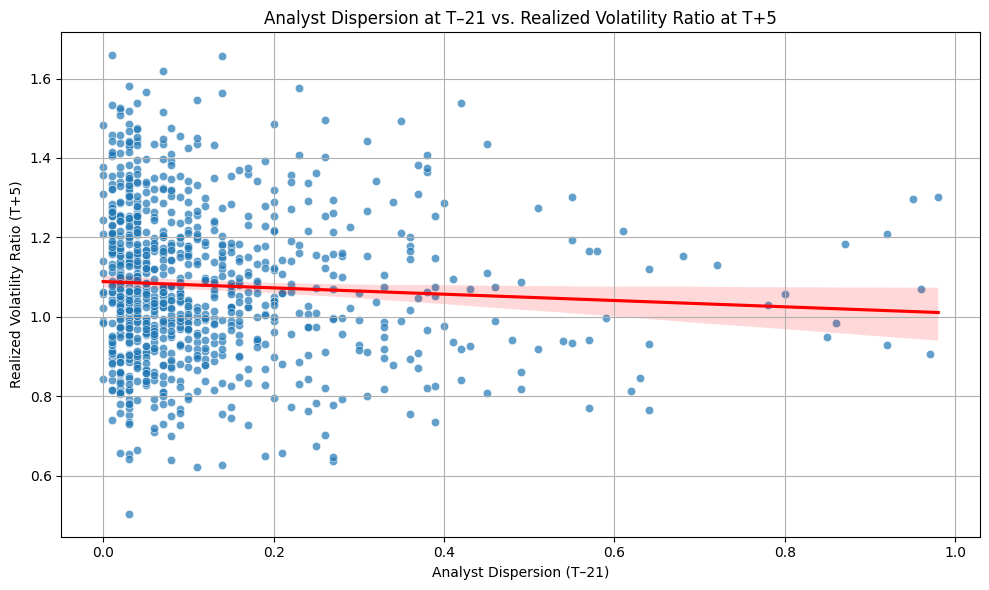

In [ ]:
plot_df = final_df.dropna(subset=['dispersion', 'y_feature'])
plot_df = plot_df[plot_df['dispersion'] < 1]

# Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_df, x='dispersion', y='y_feature', alpha=0.7)

# Add a regression line (optional)
sns.regplot(data=plot_df, x='dispersion', y='y_feature', scatter=False, color='red')

plt.title("Analyst Dispersion at T–21 vs. Realized Volatility Ratio at T+5")
plt.xlabel("Analyst Dispersion (T–21)")
plt.ylabel("Realized Volatility Ratio (T+5)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
Famafrench
# # Step 1: Drop NaNs
# plot_df = final_df.dropna(subset=['dispersion', 'y_feature', 'ticker'])

# # Step 2: Sample 4–5 random tickers with enough data
# eligible_tickers = plot_df['ticker'].value_counts()
# sample_tickers = eligible_tickers[eligible_tickers > 2].sample(5, random_state=42).index.tolist()

# # Step 3: Plot for each ticker
# fig, axes = plt.subplots(nrows=len(sample_tickers), figsize=(10, 5 * len(sample_tickers)))

# for i, ticker in enumerate(sample_tickers):
#     ax = axes[i] if len(sample_tickers) > 1 else axes

#     subset = plot_df[plot_df['ticker'] == ticker]

#     sns.scatterplot(data=subset, x='dispersion', y='y_feature', alpha=0.7, ax=ax)
#     sns.regplot(data=subset, x='dispersion', y='y_feature', scatter=False, color='red', ax=ax)

#     ax.set_title(f"{ticker}: Dispersion at T–21 vs Realized Vol Ratio at T+5")
#     ax.set_xlabel("Analyst Dispersion (T–21)")
#     ax.set_ylabel("Realized Volatility Ratio (T+5)")
#     ax.grid(True)

# plt.tight_layout()

ibes_estimates['dispersion'] = ibes_estimates['stdev'] / ibes_estimates['meanest'].abs()
ibes_estimates[ibes_estimates['dispersion'] > 1]

,ticker,cusip,statpers,fpedats,anndats_act,meanest,stdev,numest,fpi,dispersion
242,03E9,19260Q10,2022-03-17,2022-03-31,2022-05-10,-0.02,0.64,11.0,6,32.0
243,03E9,19260Q10,2022-04-14,2022-03-31,2022-05-10,-0.03,0.52,14.0,6,17.333333
249,03E9,19260Q10,2022-03-17,2022-06-30,2022-08-09,0.04,0.51,12.0,7,12.75
250,03E9,19260Q10,2022-04-14,2022-06-30,2022-08-09,-0.03,0.55,15.0,7,18.333333
259,03E9,19260Q10,2022-03-17,2022-09-30,2022-11-03,-0.28,0.45,12.0,8,1.607143
...,...,...,...,...,...,...,...,...,...,...
22689,WYNN,98313410,2022-08-18,2023-06-30,2023-08-09,0.25,0.44,5.0,9,1.76
22690,WYNN,98313410,2022-09-15,2023-06-30,2023-08-09,0.65,1.06,6.0,9,1.630769
22691,WYNN,98313410,2022-10-20,2023-06-30,2023-08-09,0.6,1.07,6.0,9,1.783333
22692,WYNN,98313410,2022-11-17,2023-09-30,2023-11-09,-0.06,0.41,5.0,9,6.833333


In [ ]:
# quick regression to check if there is a relation
final_df

import statsmodels.api as sm

ols_df = final_df[['y_feature', 'dispersion']].replace([np.inf, -np.inf], np.nan).dropna()

X = (np.array(ols_df['dispersion']))
y = np.array(ols_df['y_feature'])

X = sm.add_constant(X)
model = sm.OLS(y, X)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.6369
Date:                Wed, 06 Aug 2025   Prob (F-statistic):              0.425
Time:                        22:05:27   Log-Likelihood:                 257.43
No. Observations:                 985   AIC:                            -510.9
Df Residuals:                     983   BIC:                            -501.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0773      0.006    179.336      0.0

In [ ]:
prices_df#[prices_df['cusip']=='G7997R10']
aligned_df[aligned_df['ticker']=='AAPL']

,gvkey,cusip,ticker,datadate,earnings_date,fyearq,fqtr,cusip8,target_date,secid,date,y_feature,dispersion_lookup_date
16,001690,037833100,AAPL,2021-12-31,2022-01-27,2022,1,03783310,2022-02-01,101594.0,2022-02-01,1.045874,2021-12-29
17,001690,037833100,AAPL,2022-03-31,2022-04-28,2022,2,03783310,2022-05-03,101594.0,2022-05-03,0.974438,2022-03-30
18,001690,037833100,AAPL,2022-06-30,2022-07-28,2022,3,03783310,2022-08-02,101594.0,2022-08-02,0.913400,2022-06-29
19,001690,037833100,AAPL,2022-09-30,2022-10-27,2022,4,03783310,2022-11-01,101594.0,2022-11-01,1.238208,2022-09-28


In [ ]:
def align_realized_vol_to_earnings(realized_vol_df, earnings_df, window=5):
    """
    Aligns post-earnings realized volatility (y_feature) to T+window.
    Assumes 'earnings_date' is in earnings_df and 'date' is in realized_vol_df.

    Returns:
        Merged DataFrame with y_feature at T+window for each earnings event.
    """
    earnings_df['earnings_date'] = pd.to_datetime(earnings_df['earnings_date'])
    realized_vol_df['date'] = pd.to_datetime(realized_vol_df['date'])

    # Merge and find the closest match for earnings_date + window
    target_dates = earnings_df.copy()
    target_dates['target_date'] = target_dates['earnings_date'] + pd.Timedelta(days=window)

    # Inner join to find exact matches
    merged = pd.merge(
        target_dates,
        realized_vol_df,
        left_on=['ticker', 'target_date'],
        right_on=['ticker', 'date'],
        how='left'
    )

    return merged.dropna(subset=['y_feature'])

def merge_with_ibes_dispersion(aligned_df, ibes_dispersion_df):
    """
    Joins realized volatility (y_feature) with IBES dispersion.
    Matches on ticker and fiscal period end date (fpedats ≈ earnings_date).
    """
    ibes_dispersion_df['fpedats'] = pd.to_datetime(ibes_dispersion_df['fpedats'])
    aligned_df['earnings_date'] = pd.to_datetime(aligned_df['earnings_date'])

    # Use fuzzy join logic: fpedats == fiscal quarter end matching earnings_date
    merged = pd.merge(
        aligned_df,
        ibes_dispersion_df[['ticker', 'fpedats', 'dispersion']],
        left_on=['ticker', 'fyearq'],
        right_on=['ticker', 'fpedats'],
        how='inner'
    )

    return merged.dropna(subset=['dispersion', 'y_feature'])


import matplotlib.pyplot as plt
import seaborn as sns

def plot_dispersion_vs_vol(df):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df, x='dispersion', y='y_feature', hue='ticker', alpha=0.6)
    plt.title("Analyst Dispersion vs. Realized Relative Volatility (T+5)")
    plt.xlabel("Analyst Dispersion (IBES)")
    plt.ylabel("Post-Earnings Relative Volatility (y_feature)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [13]:
# Step 1: Align volatility to T+5 post earnings
aligned_df = align_realized_vol_to_earnings(realized_vol_df, earnings_df)

# # Step 2: Merge with IBES dispersion data
# final_df = merge_with_ibes_dispersion(aligned_df, ibes_dispersion_df)

# # Step 3: Scatter plot
# plot_dispersion_vs_vol(final_df)

NameError: name 'realized_vol_df' is not defined

In [ ]:
query = """
SELECT * FROM tr_ibes.recdsum
WHERE Ticker = 'MSFT'
AND statpers BETWEEN '2005-01-01' AND '2005-03-31'
"""

recommendation_summary = db.raw_sql(query).sort_values(by=['statpers'])
recommendation_summary

,ticker,cusip,oftic,cname,statpers,meanrec,medrec,stdev,numrec,numup,numdown,buypct,sellpct,holdpct,usfirm
0,MSFT,59491810,MSFT,MICROSOFT CP,2005-01-20,1.69,2.0,0.81,29.0,0.0,0.0,96.55,3.45,0.0,1
1,MSFT,59491810,MSFT,MICROSOFT CP,2005-02-17,1.73,2.0,0.83,30.0,0.0,0.0,93.33,3.33,3.33,1
2,MSFT,59491810,MSFT,MICROSOFT CP,2005-03-17,1.71,2.0,0.82,31.0,0.0,0.0,93.55,3.23,3.23,1


In [ ]:
# Recommendation details

# query = """
# SELECT * FROM tr_ibes.recddet
# WHERE Ticker = 'MSFT'
# AND statpers BETWEEN '2005-01-01' AND '2005-01-31'
# """

query = """
SELECT * FROM tr_ibes.det_epsus
WHERE Ticker in ('MSFT','AAPL')
AND actdats BETWEEN '2005-01-01' AND '2005-01-31'
"""

recommendation_detail = db.raw_sql(query)
recommendation_detail

,ticker,cusip,oftic,cname,actdats,estimator,analys,currfl,pdf,fpi,...,revtims,anndats,anntims,actual,actdats_act,acttims_act,anndats_act,anntims_act,curr_act,report_curr
0,AAPL,03783310,AAPL,APPLE COMPUTER,2005-01-07,118.0,70648.0,<NA>,D,0,...,20:06:42,2005-01-06,18:35:00,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,USD
1,AAPL,03783310,AAPL,APPLE COMPUTER,2005-01-04,873.0,72446.0,<NA>,D,6,...,09:54:52,2005-01-04,00:58:00,0.0125,2005-01-12,17:12:00,2005-01-12,16:50:00,USD,USD
2,AAPL,03783310,AAPL,APPLE COMPUTER,2005-01-05,118.0,70648.0,<NA>,D,6,...,00:54:34,2005-01-05,06:35:00,0.0125,2005-01-12,17:12:00,2005-01-12,16:50:00,USD,USD
3,AAPL,03783310,AAPL,APPLE COMPUTER,2005-01-07,104.0,78117.0,<NA>,D,6,...,09:17:24,2005-01-07,05:36:00,0.0125,2005-01-12,17:12:00,2005-01-12,16:50:00,USD,USD
4,AAPL,03783310,AAPL,APPLE COMPUTER,2005-01-11,16.0,10014.0,<NA>,D,6,...,10:15:19,2005-01-10,20:18:00,0.0125,2005-01-12,17:12:00,2005-01-12,16:50:00,USD,USD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343,MSFT,59491810,MSFT,MICROSOFT CP,2005-01-28,171.0,43891.0,<NA>,D,O,...,08:18:33,2005-01-28,08:34:00,0.31,2006-07-20,16:28:00,2006-07-20,16:23:00,USD,USD
344,MSFT,59491810,MSFT,MICROSOFT CP,2005-01-07,39.0,59247.0,<NA>,D,P,...,11:28:24,2005-01-07,09:54:00,0.31,2006-07-20,16:28:00,2006-07-20,16:23:00,USD,USD
345,MSFT,59491810,MSFT,MICROSOFT CP,2005-01-10,899.0,75490.0,<NA>,D,P,...,09:14:02,2005-01-05,11:33:00,0.31,2006-07-20,16:28:00,2006-07-20,16:23:00,USD,USD
346,MSFT,59491810,MSFT,MICROSOFT CP,2005-01-10,899.0,75490.0,<NA>,D,P,...,11:24:06,2005-01-10,13:31:00,0.31,2006-07-20,16:28:00,2006-07-20,16:23:00,USD,USD


In [7]:
def compute_next_quarter_dispersion(db, cusip_list, start_date, end_date):
    """
    Compute monthly dispersion of analyst forecasts for next quarter earnings
    using unadjusted I/B/E/S Detail EPSUS data.

    Parameters:
        db (wrds.Connection): WRDS database connection
        ticker_list (list): List of tickers (e.g., ['AAPL', 'MSFT'])
        start_date (str): Start date of analysis (e.g., '2005-01-01')
        end_date (str): End date of analysis (e.g., '2023-12-31')

    Returns:
        pd.DataFrame: ['ticker', 'month_end', 'dispersion', 'num_analysts']
    """
    ticker_str = "', '".join(cusip_list)

    query = f"""
        SELECT ticker, cusip, actdats, fpedats, estimator, analys, value, fpi
        FROM tr_ibes.det_epsus
        WHERE ticker IN ('{cusip_list}')
          AND actdats BETWEEN '{start_date}' AND '{end_date}'
          AND fpi IN ('6', '7', '8', '9')
          AND value IS NOT NULL
    """
    df = db.raw_sql(query, date_cols=['actdats', 'fpedats'])

    # Add month-end for binning
    df['month_end'] = df['actdats'] + pd.offsets.MonthEnd(0)

    # Keep only the nearest future forecast per firm-month
    df = df[df['fpedats'] >= df['actdats']]  # Only forward-looking
    df['forecast_horizon'] = (df['fpedats'] - df['actdats']).dt.days

    df = (
        df.sort_values(['ticker', 'month_end', 'forecast_horizon'])
          .groupby(['ticker', 'month_end'])
          .filter(lambda x: x['forecast_horizon'].min() == x['forecast_horizon'].iloc[0])
    )

    # Compute dispersion
    dispersion_df = (
        df.groupby(['ticker', 'month_end'])
        .agg(mean_est=('value', 'mean'),
             std_est=('value', 'std'),
             num_analysts=('analys', pd.Series.nunique))
        .reset_index()
    )

    dispersion_df['dispersion'] = dispersion_df['std_est'] / dispersion_df['mean_est'].abs()
    dispersion_df = dispersion_df[dispersion_df['num_analysts'] >= 2]

    return dispersion_df[['ticker', 'month_end', 'dispersion', 'num_analysts']]


In [14]:
compute_next_quarter_dispersion(db, ['AAPL', 'MSFT'], '2023-01-01', '2023-12-31')

PendingRollbackError: Can't reconnect until invalid transaction is rolled back.  Please rollback() fully before proceeding (Background on this error at: https://sqlalche.me/e/20/8s2b)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.tseries.offsets import BDay

def get_ibes_summary_epsus(db, cusip_list, start_date='2005-01-01', end_date='2024-12-31'):
    """
    Fetch IBES summary EPS data by CUSIP list.
    """
    cusip_str = ', '.join(f"'{cusip}'" for cusip in cusip_list)
    query = f"""
        SELECT ticker, cusip, statpers, fpedats, meanest, stdev, numest, fpi
        FROM tr_ibes.statsum_epsus
        WHERE cusip IN ({cusip_str})
          AND statpers BETWEEN '{start_date}' AND '{end_date}'
          AND measure = 'EPS'
          AND fiscalp = 'QTR'
          AND fpi IN ('6', '7', '8', '9')
    """
    df = db.raw_sql(query, date_cols=['statpers', 'fpedats'])
    df['dispersion'] = df['stdev'] / df['meanest'].abs()
    return df

def create_dispersion_panel(df):
    """
    Create daily panel per cusip and forward-fill dispersion.
    """
    df['statpers'] = pd.to_datetime(df['statpers'])
    full_dates = pd.date_range(df['statpers'].min(), df['statpers'].max(), freq='B')
    cusips = df['cusip'].unique()
    panel_index = pd.MultiIndex.from_product([cusips, full_dates], names=['cusip', 'date'])
    expanded_df = pd.DataFrame(index=panel_index).reset_index()
    df_renamed = df.rename(columns={'statpers': 'date'})
    merged = pd.merge(expanded_df, df_renamed[['cusip', 'date', 'dispersion']], on=['cusip', 'date'], how='left')
    merged['dispersion'] = merged.groupby('cusip')['dispersion'].ffill()
    return merged

def align_dispersion_with_earnings(aligned_df, dispersion_df):
    """
    Align dispersion with earnings date (T-21B).
    """
    aligned_df['earnings_date'] = pd.to_datetime(aligned_df['earnings_date'])
    aligned_df['dispersion_lookup_date'] = aligned_df['earnings_date'] - BDay(21)
    aligned_df['cusip8'] = aligned_df['cusip'].str[:8]
    merged = pd.merge(
        aligned_df,
        dispersion_df,
        left_on=['cusip8', 'dispersion_lookup_date'],
        right_on=['cusip', 'date'],
        how='left'
    )
    merged = merged.drop(columns=['date'])
    return merged

def plot_dispersion_vs_yfeature(final_df):
    """
    Scatter and regression plot of dispersion vs y_feature.
    """
    plot_df = final_df.dropna(subset=['dispersion', 'y_feature'])
    plot_df = plot_df[plot_df['dispersion'] < 1]

    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=plot_df, x='dispersion', y='y_feature', alpha=0.7)
    sns.regplot(data=plot_df, x='dispersion', y='y_feature', scatter=False, color='red')

    plt.title("Analyst Dispersion at T–21 vs. Realized Volatility Ratio at T+5")
    plt.xlabel("Analyst Dispersion (T–21)")
    plt.ylabel("Realized Volatility Ratio (T+5)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return plot_df


def run_dispersion_pipeline(
    db,
    cusip_list,
    earnings_df,
    realized_vol_df,
    y_feature_col='y_feature',
    start_date='2005-01-01',
    end_date='2024-12-31'
):
    """
    Full pipeline to extract IBES dispersion, align it to earnings events, and visualize relationship with realized volatility.

    Parameters:
    - db: Active WRDS connection
    - cusip_list: List of 8-digit CUSIPs
    - earnings_df: DataFrame with 'cusip' and 'earnings_date'
    - realized_vol_df: DataFrame with ['ticker', 'date', y_feature_col]
    - y_feature_col: Name of target column (e.g., 'y_feature')
    - start_date: Earliest statpers to query from IBES
    - end_date: Latest statpers to query from IBES

    Returns:
    - final_df: Merged and aligned DataFrame
    - plot_df: Cleaned subset for plotting
    """
    # Step 1: Get IBES EPS summary dispersion
    ibes_df = get_ibes_summary_epsus(db, cusip_list, start_date, end_date)

    # Step 2: Create daily forward-filled dispersion panel
    dispersion_panel = create_dispersion_panel(ibes_df)

    # Step 3: Align dispersion with earnings (T-21B)
    aligned_df = align_dispersion_with_earnings(earnings_df.copy(), dispersion_panel)

    # Step 4: Merge with realized volatility y_feature
    realized_vol_df['date'] = pd.to_datetime(realized_vol_df['date'])
    final_df = pd.merge(
        aligned_df,
        realized_vol_df[['ticker', 'date', y_feature_col]],
        left_on=['ticker', 'earnings_date'],
        right_on=['ticker', 'date'],
        how='left'
    ).drop(columns=['date'])

    # Step 5: Plot and return results
    plot_df = plot_dispersion_vs_yfeature(final_df)
    return final_df, plot_df


import pandas as pd
import numpy as np
from pandas.tseries.offsets import BDay

def compute_detailed_dispersion_vectorized(det_df, earnings_df, lookback_days=21):
    """
    Vectorized computation of analyst dispersion using IBES detail_epsus forecasts.

    Parameters:
        det_df (pd.DataFrame): IBES detail_epsus data with columns:
            ['cusip', 'fpedats', 'value', 'anndats', 'actdats']
        earnings_df (pd.DataFrame): DataFrame with earnings data:
            ['cusip', 'earnings_date']
        lookback_days (int): Number of business days before earnings to calculate dispersion

    Returns:
        pd.DataFrame: ['cusip8', 'earnings_date', 'dispersion']
    """
    # Ensure datetime formats
    det_df = det_df.copy()
    det_df['anndats'] = pd.to_datetime(det_df['anndats'])
    det_df['fpedats'] = pd.to_datetime(det_df['fpedats'])
    det_df['actdats'] = pd.to_datetime(det_df['actdats'])

    earnings_df = earnings_df.copy()
    earnings_df['lookup_date'] = pd.to_datetime(earnings_df['earnings_date']) - BDay(lookback_days)
    earnings_df['cusip8'] = earnings_df['cusip'].str[:8]

    # Merge to bring earnings info into forecasts
    merged = pd.merge(
        det_df,
        earnings_df[['cusip8', 'earnings_date', 'lookup_date']],
        left_on=det_df['cusip'].str[:8],
        right_on='cusip8',
        how='inner'
    )

    # Filter for forecasts made before lookup date and for correct earnings quarter
    valid_forecasts = merged[
        (merged['anndats'] <= merged['lookup_date']) &
        (merged['fpedats'] == merged['earnings_date'])
    ]

    # Compute dispersion = std / |mean| for each (cusip8, earnings_date)
    dispersion_grouped = valid_forecasts.groupby(['cusip8', 'earnings_date'])['value']
    dispersion_df = dispersion_grouped.agg(['mean', 'std']).reset_index()
    dispersion_df['dispersion'] = dispersion_df['std'] / dispersion_df['mean'].abs()

    # Return only relevant columns
    return dispersion_df[['cusip8', 'earnings_date', 'dispersion']]


import pandas as pd
import numpy as np
from pandas.tseries.offsets import BDay
import matplotlib.pyplot as plt
import seaborn as sns

def compute_detailed_dispersion_vectorized(det_df, earnings_df, lookback_days=21):
    """
    Vectorized computation of analyst dispersion using IBES detail_epsus forecasts.

    Parameters:
        det_df (pd.DataFrame): IBES detail_epsus data with columns:
            ['cusip', 'fpedats', 'value', 'anndats', 'actdats']
        earnings_df (pd.DataFrame): DataFrame with earnings data:
            ['cusip', 'earnings_date']
        lookback_days (int): Number of business days before earnings to calculate dispersion

    Returns:
        pd.DataFrame: ['cusip8', 'earnings_date', 'dispersion']
    """
    det_df = det_df.copy()
    det_df['anndats'] = pd.to_datetime(det_df['anndats'])
    det_df['fpedats'] = pd.to_datetime(det_df['fpedats'])
    det_df['actdats'] = pd.to_datetime(det_df['actdats'])

    earnings_df = earnings_df.copy()
    earnings_df['lookup_date'] = pd.to_datetime(earnings_df['earnings_date']) - BDay(lookback_days)
    earnings_df['cusip8'] = earnings_df['cusip'].str[:8]

    merged = pd.merge(
        det_df,
        earnings_df[['cusip8', 'earnings_date', 'lookup_date']],
        left_on=det_df['cusip'].str[:8],
        right_on='cusip8',
        how='inner'
    )

    valid_forecasts = merged[
        (merged['anndats'] <= merged['lookup_date']) &
        (merged['fpedats'] == merged['earnings_date'])
    ]

    dispersion_grouped = valid_forecasts.groupby(['cusip8', 'earnings_date'])['value']
    dispersion_df = dispersion_grouped.agg(['mean', 'std']).reset_index()
    dispersion_df['dispersion'] = dispersion_df['std'] / dispersion_df['mean'].abs()

    return dispersion_df[['cusip8', 'earnings_date', 'dispersion']]


def run_detailed_dispersion_pipeline(
    det_df,
    earnings_df,
    realized_vol_df,
    y_feature_col='y_feature',
    lookback_days=21
):
    """
    Complete pipeline using IBES detailed estimates (det_epsus) to compute analyst dispersion
    and align with realized volatility features.

    Parameters:
    - det_df (DataFrame): IBES detail_epsus data with columns ['cusip', 'fpedats', 'value', 'anndats', 'actdats']
    - earnings_df (DataFrame): Earnings events with ['cusip', 'ticker', 'earnings_date']
    - realized_vol_df (DataFrame): Realized volatility features with ['ticker', 'date', y_feature_col]
    - y_feature_col (str): Name of the target column to regress against (default 'y_feature')
    - lookback_days (int): How many business days before earnings to compute dispersion

    Returns:
    - final_df (DataFrame): DataFrame ready for analysis
    - plot_df (DataFrame): Subset for plotting
    """
    # Step 1: Compute dispersion from detailed forecasts
    dispersion_df = compute_detailed_dispersion_vectorized(det_df, earnings_df, lookback_days=lookback_days)

    # Step 2: Preprocess and align earnings + realized volatility
    earnings_df['cusip8'] = earnings_df['cusip'].str[:8]
    earnings_df['earnings_date'] = pd.to_datetime(earnings_df['earnings_date'])
    realized_vol_df['date'] = pd.to_datetime(realized_vol_df['date'])

    # Step 3: Merge dispersion into earnings events
    merged_df = earnings_df.merge(dispersion_df, on=['cusip8', 'earnings_date'], how='left')

    # Step 4: Merge with realized volatility (y_feature) at earnings date
    final_df = pd.merge(
        merged_df,
        realized_vol_df[['ticker', 'date', y_feature_col]],
        left_on=['ticker', 'earnings_date'],
        right_on=['ticker', 'date'],
        how='left'
    ).drop(columns=['date'])

    # Step 5: Filter for valid rows
    plot_df = final_df.dropna(subset=['dispersion', y_feature_col])
    plot_df = plot_df[plot_df['dispersion'] < 1]

    # Step 6: Scatterplot with regression line
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=plot_df, x='dispersion', y=y_feature_col, alpha=0.7)
    sns.regplot(data=plot_df, x='dispersion', y=y_feature_col, scatter=False, color='red')
    plt.title(f"Analyst Dispersion (T–{lookback_days}) vs {y_feature_col} at T+5")
    plt.xlabel(f"Analyst Dispersion (T–{lookback_days})")
    plt.ylabel(y_feature_col)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return final_df, plot_df


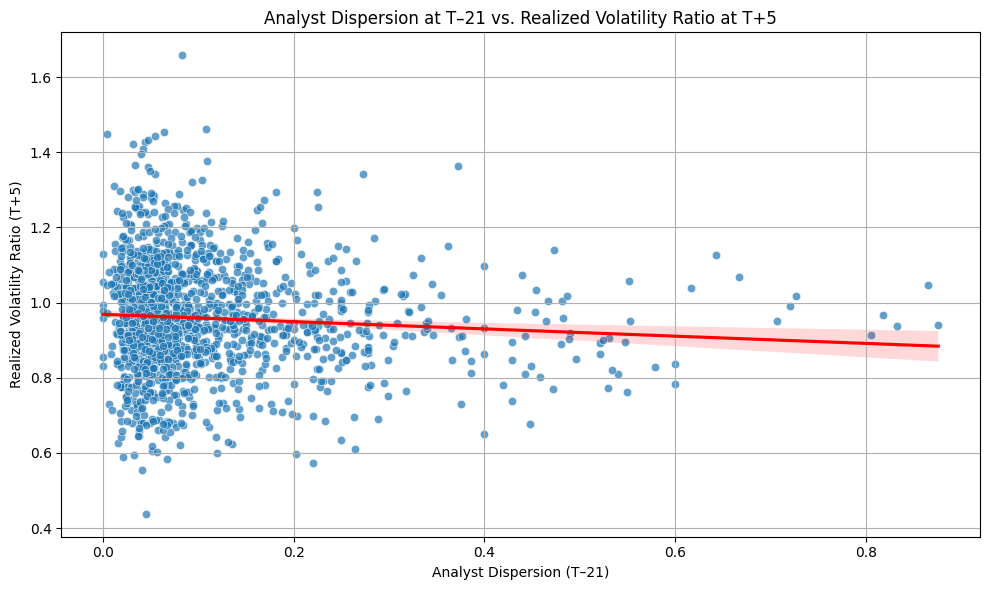

In [ ]:
final_df, plot_df = run_dispersion_pipeline(
    db=db,
    cusip_list=earnings_df['cusip'].str[:8].unique().tolist(),
    earnings_df=earnings_df,
    realized_vol_df=realized_vol_df,
    y_feature_col='y_feature',
    start_date='2022-01-01',
    end_date='2023-01-01'
)


In [ ]:
earnings_df

,gvkey,cusip,ticker,datadate,earnings_date,fyearq,fqtr,cusip8
0,001209,009158106,APD,2021-12-31,2022-02-04,2022,1,00915810
1,001209,009158106,APD,2022-03-31,2022-05-05,2022,2,00915810
2,001209,009158106,APD,2022-06-30,2022-08-04,2022,3,00915810
3,001209,009158106,APD,2022-09-30,2022-11-03,2022,4,00915810
4,001440,025537101,AEP,2021-12-31,2022-02-24,2021,4,02553710
...,...,...,...,...,...,...,...,...
1972,185532,87612G101,TRGP,2022-09-30,2022-11-03,2022,3,87612G10
1973,189491,98419M100,XYL,2021-12-31,2022-02-03,2021,4,98419M10
1974,189491,98419M100,XYL,2022-03-31,2022-05-04,2022,1,98419M10
1975,189491,98419M100,XYL,2022-06-30,2022-08-02,2022,2,98419M10


In [ ]:
final_df, plot_df = full_dispersion_analysis_pipeline(
    det_df=det_epsus_df,
    earnings_df=earnings_date,
    realized_vol_df=realized_vol_df,
    y_feature_col='y_feature',
    lookback_days=21
)


NameError: name 'det_epsus_df' is not defined

In [ ]:
def full_dispersion_analysis_pipeline(
    db,
    cusip_list,
    earnings_df,
    realized_vol_df,
    start_date='2005-01-01',
    end_date='2024-12-31',
    y_feature_col='y_feature',
    lookback_days=21,
    use_detailed=True
):
    """
    Runs the full dispersion analysis pipeline using either IBES summary or detailed EPS estimates.

    Parameters:
    - db: WRDS database connection
    - cusip_list: List of CUSIPs to analyze
    - earnings_df: DataFrame with ['cusip', 'ticker', 'earnings_date']
    - realized_vol_df: DataFrame with ['ticker', 'date', y_feature_col]
    - start_date: Start date for IBES queries
    - end_date: End date for IBES queries
    - y_feature_col: Realized volatility target column
    - lookback_days: Days before earnings for dispersion
    - use_detailed: Boolean, True for det_epsus, False for statsum_epsus

    Returns:
    - final_df: Full merged dataset
    - plot_df: Cleaned subset for plotting
    """

    if use_detailed:
        # Step 1: Pull IBES detailed estimates
        cusip_str = ', '.join(f"'{cusip}'" for cusip in cusip_list)
        query = f"""
            SELECT ticker, cusip, fpedats, value, anndats, actdats
            FROM tr_ibes.det_epsus
            WHERE cusip IN ({cusip_str})
              AND actdats BETWEEN '{start_date}' AND '{end_date}'
              AND measure = 'EPS'
              AND fpi IN ('6', '7', '8', '9')
        """
        det_epsus_df = db.raw_sql(query, date_cols=['anndats', 'fpedats', 'actdats'])

        # Step 2: Run dispersion pipeline using detailed data
        final_df, plot_df = run_detailed_dispersion_pipeline(
            det_df=det_epsus_df,
            earnings_df=earnings_df,
            realized_vol_df=realized_vol_df,
            y_feature_col=y_feature_col,
            lookback_days=lookback_days
        )

    else:
        # Step 1: Use summary pipeline
        final_df, plot_df = run_dispersion_pipeline(
            db=db,
            cusip_list=cusip_list,
            earnings_df=earnings_df,
            realized_vol_df=realized_vol_df,
            y_feature_col=y_feature_col,
            start_date=start_date,
            end_date=end_date
        )

    return final_df, plot_df
